# Fine-tune DistilBERT for Issue Classification

Fine-tune `distilbert-base-uncased` on the train split.  
Validate on val split. Final numbers reported on test split.

**Why DistilBERT?**
- 40% smaller than BERT-base, 60% faster, retains 97% of BERT's performance
- Fits comfortably in a CPU/single-GPU environment
- Fast enough to iterate during the course week

**Goal:** beat the TF-IDF baseline macro F1 and pass all `eval_thresholds.yaml` gates.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yaml

from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

SPLITS     = '../data/splits'
CLASSES    = ['bug', 'feature', 'docs', 'question']
ID2LABEL   = {i: c for i, c in enumerate(CLASSES)}
LABEL2ID   = {c: i for i, c in enumerate(CLASSES)}
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256
BATCH_SIZE = 32
EPOCHS     = 4
LR         = 2e-5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Load Data

In [2]:
train_df = pd.read_parquet(f'{SPLITS}/train.parquet')
val_df   = pd.read_parquet(f'{SPLITS}/val.parquet')
test_df  = pd.read_parquet(f'{SPLITS}/test.parquet')

def make_text(df):
    return (df['title'].fillna('') + ' [SEP] ' + df['body'].fillna('')).str.strip()

for df in [train_df, val_df, test_df]:
    df['text']  = make_text(df)
    df['label_id'] = df['mapped_label'].map(LABEL2ID)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
print(train_df['mapped_label'].value_counts())

Train: 1,862  Val: 399  Test: 401
mapped_label
bug         854
feature     378
docs        360
question    270
Name: count, dtype: int64


## 2. Dataset & DataLoader

In [3]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)


class IssueDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }


train_ds = IssueDataset(train_df['text'], train_df['label_id'], tokenizer, MAX_LEN)
val_ds   = IssueDataset(val_df['text'],   val_df['label_id'],   tokenizer, MAX_LEN)
test_ds  = IssueDataset(test_df['text'],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 59, val: 13, test: 13


## 3. Model Setup

Class weights compensate for the docs imbalance.

In [4]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASSES),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASSES)),
    y=train_df['label_id'].values,
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

print(f'Class weights: {dict(zip(CLASSES, class_weights.round(2)))}')
print(f'Total training steps: {total_steps}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6569.82it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: {'bug': np.float64(0.55), 'feature': np.float64(1.23), 'docs': np.float64(1.29), 'question': np.float64(1.72)}
Total training steps: 236


## 4. Training Loop

In [5]:
def run_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(training):
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            all_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), macro_f1


history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_val_f1, best_epoch = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1 = run_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_f1 = run_epoch(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    marker = ' ← best' if vl_f1 > best_val_f1 else ''
    if vl_f1 > best_val_f1:
        best_val_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch {epoch}/{EPOCHS} | '
          f'train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | '
          f'val_loss={vl_loss:.4f} val_f1={vl_f1:.4f}{marker}')

print(f'\nBest val macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Epoch 1/4 | train_loss=1.1553 train_f1=0.5091 | val_loss=1.0531 val_f1=0.4616 ← best
Epoch 2/4 | train_loss=0.6416 train_f1=0.7787 | val_loss=0.8617 val_f1=0.5450 ← best
Epoch 3/4 | train_loss=0.4765 train_f1=0.8393 | val_loss=0.6890 val_f1=0.6413 ← best
Epoch 4/4 | train_loss=0.4175 train_f1=0.8660 | val_loss=0.6571 val_f1=0.6516 ← best

Best val macro F1: 0.6516 at epoch 4


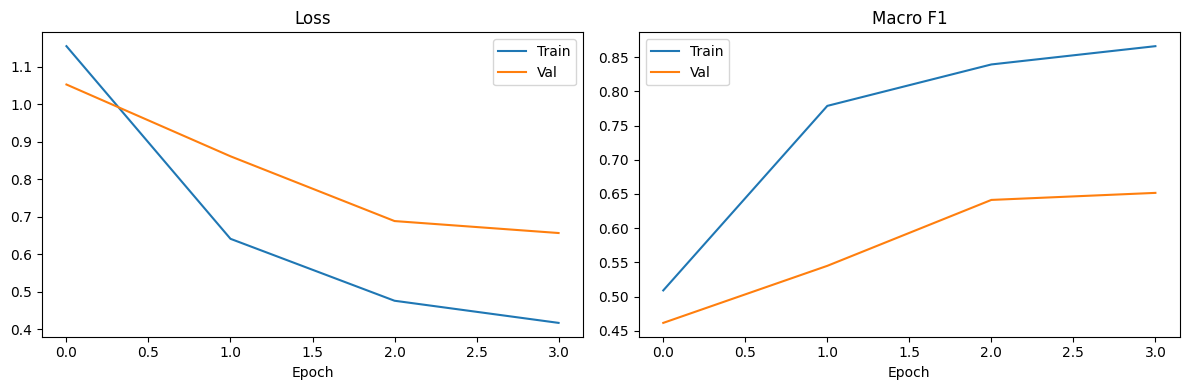

In [6]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_f1'], label='Train')
ax2.plot(history['val_f1'],   label='Val')
ax2.set_title('Macro F1')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Test Evaluation (best checkpoint)

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE),
        )
        all_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

y_pred_names = [ID2LABEL[p] for p in all_preds]
y_true_names = [ID2LABEL[l] for l in all_labels]

test_accuracy = accuracy_score(all_labels, all_preds)
test_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Accuracy:      {test_accuracy:.4f}')
print(f'Test Macro F1: {test_macro_f1:.4f}')
print(classification_report(y_true_names, y_pred_names, target_names=CLASSES, zero_division=0))

Accuracy:      0.6584
Test Macro F1: 0.6350
              precision    recall  f1-score   support

         bug       0.84      0.62      0.72       183
     feature       0.95      0.90      0.92        78
        docs       0.40      0.76      0.52        82
    question       0.49      0.31      0.38        58

    accuracy                           0.66       401
   macro avg       0.67      0.65      0.64       401
weighted avg       0.72      0.66      0.67       401



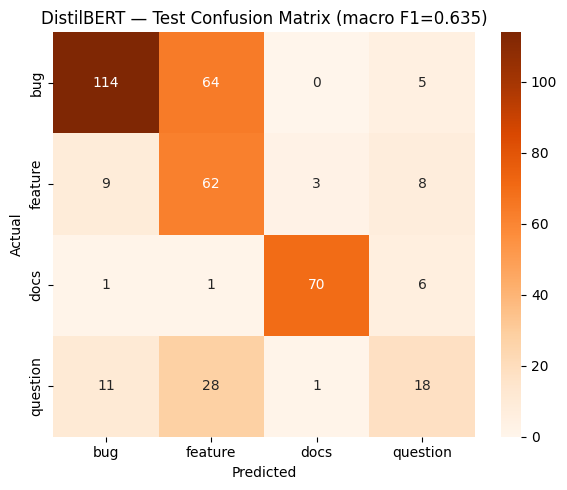

In [8]:
cm = confusion_matrix(y_true_names, y_pred_names, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'DistilBERT — Test Confusion Matrix (macro F1={test_macro_f1:.3f})')
plt.tight_layout()
plt.show()

## 6. Threshold Check

In [9]:
with open('../../eval_thresholds.yaml') as f:
    thresholds = yaml.safe_load(f)

gates  = thresholds['classification']
report = classification_report(y_true_names, y_pred_names, output_dict=True, zero_division=0)

print(f"Accuracy:  {test_accuracy:.3f}  (threshold: {gates['accuracy']})  {'PASS' if test_accuracy >= gates['accuracy'] else 'FAIL'}")
print(f"Macro F1:  {test_macro_f1:.3f}  (threshold: {gates['macro_f1']})  {'PASS' if test_macro_f1 >= gates['macro_f1'] else 'FAIL'}")
for cls in CLASSES:
    f1 = report.get(cls, {}).get('f1-score', 0)
    thr = gates['per_class'].get(cls, 0)
    print(f"  {cls:<10} F1: {f1:.3f}  (threshold: {thr})  {'PASS' if f1 >= thr else 'FAIL'}")

Accuracy:  0.658  (threshold: 0.7)  FAIL
Macro F1:  0.635  (threshold: 0.7)  FAIL
  bug        F1: 0.717  (threshold: 0.65)  PASS
  feature    F1: 0.523  (threshold: 0.65)  FAIL
  docs       F1: 0.921  (threshold: 0.6)  PASS
  question   F1: 0.379  (threshold: 0.65)  FAIL


## 7. Save Model & Card

In [10]:
os.makedirs('output', exist_ok=True)

model.save_pretrained('output/')
tokenizer.save_pretrained('output/')

per_class_f1 = {cls: round(report.get(cls, {}).get('f1-score', 0), 4) for cls in CLASSES}

card = f"""# DistilBERT Issue Classifier

**Base model:** distilbert-base-uncased  
**Task:** 4-class GitHub issue classification (bug / feature / docs / question)  
**Training data:** home-assistant/core + home-assistant.io (closed issues)

## Results (test split)

| Metric | Value |
|--------|-------|
| Accuracy | {test_accuracy:.4f} |
| Macro F1 | {test_macro_f1:.4f} |
| Bug F1 | {per_class_f1['bug']} |
| Feature F1 | {per_class_f1['feature']} |
| Docs F1 | {per_class_f1['docs']} |
| Question F1 | {per_class_f1['question']} |

## Training Config

- Epochs: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Learning rate: {LR}
- Max token length: {MAX_LEN}
- Class weights: balanced
- Best checkpoint: epoch {best_epoch}
"""

with open('output/model_card.md', 'w') as f:
    f.write(card)

print('Saved model to output/')
print(card)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]

Saved model to output/
# DistilBERT Issue Classifier

**Base model:** distilbert-base-uncased  
**Task:** 4-class GitHub issue classification (bug / feature / docs / question)  
**Training data:** home-assistant/core + home-assistant.io (closed issues)

## Results (test split)

| Metric | Value |
|--------|-------|
| Accuracy | 0.6584 |
| Macro F1 | 0.6350 |
| Bug F1 | 0.717 |
| Feature F1 | 0.5232 |
| Docs F1 | 0.9211 |
| Question F1 | 0.3789 |

## Training Config

- Epochs: 4
- Batch size: 32
- Learning rate: 2e-05
- Max token length: 256
- Class weights: balanced
- Best checkpoint: epoch 4



## 8. Summary

In [11]:
print('=== DistilBERT Results (copy to compare.ipynb) ===')
print(f'accuracy   = {test_accuracy:.4f}')
print(f'macro_f1   = {test_macro_f1:.4f}')
print(f'per_class  = {per_class_f1}')
print(f'best_epoch = {best_epoch}')

=== DistilBERT Results (copy to compare.ipynb) ===
accuracy   = 0.6584
macro_f1   = 0.6350
per_class  = {'bug': 0.717, 'feature': 0.5232, 'docs': 0.9211, 'question': 0.3789}
best_epoch = 4
